In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Model Prep: Predicting Next-Day Closing Price

We’ll use a simple regression model to predict the next day’s closing price based on:
- Today’s closing price
- Moving averages
- Daily return

Our target variable is the closing price shifted one day into the future.

In [3]:
file_path = "../data/sample/AMZN_historical_sample.csv" # change file path to your data
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df["Daily Return"] = df["Close"].pct_change()
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

df["Target"] = df["Close"].shift(-1)

df.dropna(inplace=True)
df.head()

/var/folders/w_/j51psmx961g5qp6tmmyx79sr0000gn/T/ipykernel_56306/812314238.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Daily Return,MA20,MA50,Target
Date,,,,,,,,,,,,
2023-03-15 00:00:00-04:00,93.220001,96.669998,93.070000,96.199997,70731800,0.0,0.0,AMZN,0.013912,94.5550,95.9290,100.040001
2023-03-16 00:00:00-04:00,95.750000,100.989998,95.610001,100.040001,84446900,0.0,0.0,AMZN,0.039917,94.4990,96.2134,98.949997
2023-03-17 00:00:00-04:00,99.790001,100.660004,97.459999,98.949997,87300200,0.0,0.0,AMZN,-0.010896,94.5390,96.4896,97.709999
2023-03-20 00:00:00-04:00,98.410004,98.480003,95.699997,97.709999,62388900,0.0,0.0,AMZN,-0.012532,94.5645,96.7814,100.610001
2023-03-21 00:00:00-04:00,98.139999,100.849998,98.000000,100.610001,58597300,0.0,0.0,AMZN,0.029680,94.8660,97.0720,98.699997


## Model Training & Evaluation 
We're gonna train and test our model usiong the 80-20 split.
Because we're using a time-series model, using k-fold cross validation could leak future data.
Hence, we're splitting the data without shuffling.  
Then, we train a linear regression model on 80% of the data and test on the remaining 20%.

We use Mean Squared Error and R² Score to evaluate model performance.

In [5]:

features = ["Close", "MA20", "MA50", "Daily Return"]
X = df[features]
y = df["Target"]


split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error: 23.72
R² Score: 0.9305


## Understanding the Values of MSE and R²

To evaluate how well our regression model is performing, we've usec two metrics above:  
Mean Squared Error (MSE) and R² Score (Coefficient of Determination)

### Mean Squared Error (MSE)

MSE measures the average squared difference between the actual values and the predicted values.  
Smaller values are better—it means our predictions are closer to the real data.

### R² Score

R² tells us how well the model explains the variance in the target variable.  
- A score of 1 means the model predicts the target perfectly.  
- A score of 0 means the model performs no better than predicting the average.

Together, these values help us understand both the accuracy and the reliability of our predictions.

## Actual vs Predicted Closing Prices

Visualising the actual closing prices to the values predicted by our model.  

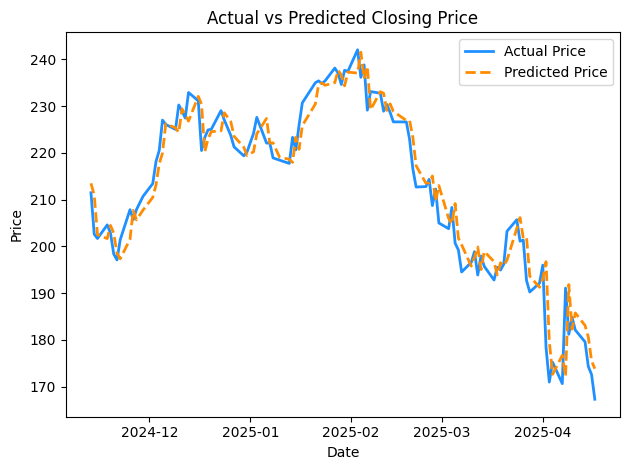

In [7]:
plt.plot(y_test.index, y_test, label="Actual Price", color="dodgerblue", linewidth=2)
plt.plot(y_test.index, y_pred, label="Predicted Price", color="darkorange", linestyle="--", linewidth=2)
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

## Actual vs Predicted Prices with Error Range

Adding a shaded region to show the absolute error between predicted and actual values, helping us visualize where the model deviates most and how consistent its predictions are.

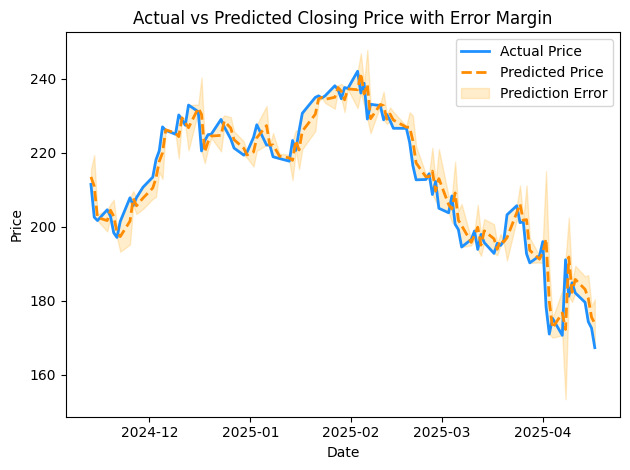

In [9]:
error = np.abs(y_test - y_pred)

plt.plot(y_test.index, y_test, label="Actual Price", color="dodgerblue", linewidth=2)
plt.plot(y_test.index, y_pred, label="Predicted Price", color="darkorange", linestyle="--", linewidth=2)
plt.fill_between(y_test.index, y_pred - error, y_pred + error, color="orange", alpha=0.2, label="Prediction Error")

plt.title("Actual vs Predicted Closing Price with Error Margin")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

## Saving Predictions to File

exporting actual vs. predicted to a .csv in `outputs/`

In [10]:
import os

os.makedirs("../outputs", exist_ok=True)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}, index=y_test.index)


output_path = "../outputs/amzn_predictions.csv" # change this to your output path
prediction_df.to_csv(output_path)
print(f"Saved predictions to {output_path}")

Saved predictions to ../outputs/amzn_predictions.csv
